In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## Data Exploration

In [ ]:
df=pd.read_excel('online_retail_II.xlsx', sheet_name=0)

In [ ]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
377402,525838,22191,IVORY DINER WALL CLOCK,2,2010-10-07 12:29:00,8.50,13552.0,United Kingdom
450174,532145,22464,HANGING METAL HEART LANTERN,6,2010-11-11 11:52:00,1.65,16412.0,United Kingdom
255376,514008,22302,COFFEE MUG PEARS DESIGN,6,2010-06-30 09:50:00,2.55,16170.0,United Kingdom
472237,533896,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,12,2010-11-19 11:48:00,0.85,16279.0,United Kingdom
300951,518681,21172,PARTY METAL SIGN,2,2010-08-10 17:09:00,1.45,17799.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

### Data contains missing values in 2 Description  and Customer ID

In [ ]:
len(df)

525461

In [ ]:
clean_df = df.dropna(subset=['Description'])

Ensures consistency in product-related analysis

Prevents noise in exploratory data analysis and modeling

Preserves the integrity of transactional insights

In [ ]:
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


Invoice numbers are expected to be 6-digit numeric values.
However, the dataset contains some entries with non-standard invoice formats (e.g., cancellations or manual adjustments).

In [ ]:
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [ ]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


All invoices starting with A correspond to adjustment entries

In [ ]:
df["StockCode"] = df["StockCode"].astype("str")
df[
    (df["StockCode"].str.match("^\\d{5}$") == False) &
    (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)
]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

### Data Cleaning

In [ ]:
cleaned_df = df.copy()

In [ ]:
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
cleaned_df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array([''], dtype=object)

Cleaned transactional data by filtering valid 6-digit invoice records and removing cancellations, returns, and accounting adjustments to ensure accurate sales analysis.

In [ ]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")

mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
    | (cleaned_df["StockCode"].str.match("^PADS$") == True)
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
cleaned_df[
    ~(
        cleaned_df["StockCode"].str.match(r"^\d{5}([A-Z]+)?$")
        | cleaned_df["StockCode"].eq("PADS")
    )
]["StockCode"].unique()

array(['72349b', '72529w', '72807c', '84797b', '84872a', '84873a',
       '85114b', '18096c', '84797a', '85014b', '85132a', '18098c',
       '48173c', '79070b', '84030c', '84558a', '47518f', '15056bl',
       '35004c', '84796b', '85040a', '85164b', '84705b', '35004s',
       '84509c', '84951b', '37482p', '85114c', '37494a', '84406b',
       '72807b', '85232b', '85159b', '47567b', '85124b', '85184c',
       '79051a', '85114a', '37482b', '79302m', '84509a', '84912a',
       '85123b', '84029c', '84030b', '84596e', '72801d', '84993b',
       '84989b', '84993a', '84867b', '84559a', '82613a', '82613b',
       '82613c', '84884a', '85039a', '47559b', '85035b', '79066k',
       '85039b', '72801c', '79342b', '84997d', '47556b', '72351a',
       '72801g', '84520b', '15060b', '84661c', '85160a', '85132b',
       '85160b', '84796a', '72807a', '84536a', '85231e', '72801e',
       '84510e', '84596j', '85232a', '84997a', '85040b', '82494l',
       '47594a', '84867a', '84660c', '84970l', '85124a', '849

Improved product data quality by removing invalid and non-merchandise stock codes, enabling accurate sales and inventory analysis.

In [ ]:
cleaned_df.dropna(subset=["Customer ID"], inplace=True)

In [ ]:
cleaned_df["Customer ID"].isnull().sum()

0

In [ ]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.000000,406337,406337.000000,406337.000000
mean,13.619099,2010-07-01 10:11:06.543288320,2.991462,15373.632992
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000659,NaN,4.285876,1677.365907


In [ ]:
len(cleaned_df[cleaned_df["Price"] == 0])

28

In [ ]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0.0]

In [ ]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.000000,406309,406309.000000,406309.000000
mean,13.617924,2010-07-01 10:14:25.869572352,2.991668,15373.722268
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,96.998833,NaN,4.285951,1677.329470


In [ ]:
cleaned_df["Price"].min()

0.001

In [ ]:
len(cleaned_df)/len(df)*100

77.32429238325965

### Feature Engineering

In [ ]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

Converted transaction-level sales data into customer-level metrics total Sales.

In [ ]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


This aggregation transforms transactional data into customer-level features that summarize spending behavior, purchase frequency, and recency. These features are essential for customer segmentation, RFM analysis, and predictive modeling.

In [ ]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()
aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


Recency captures customer engagement by measuring how recently a customer transacted. It is a strong predictor of churn, repeat purchase, and response to marketing campaigns.

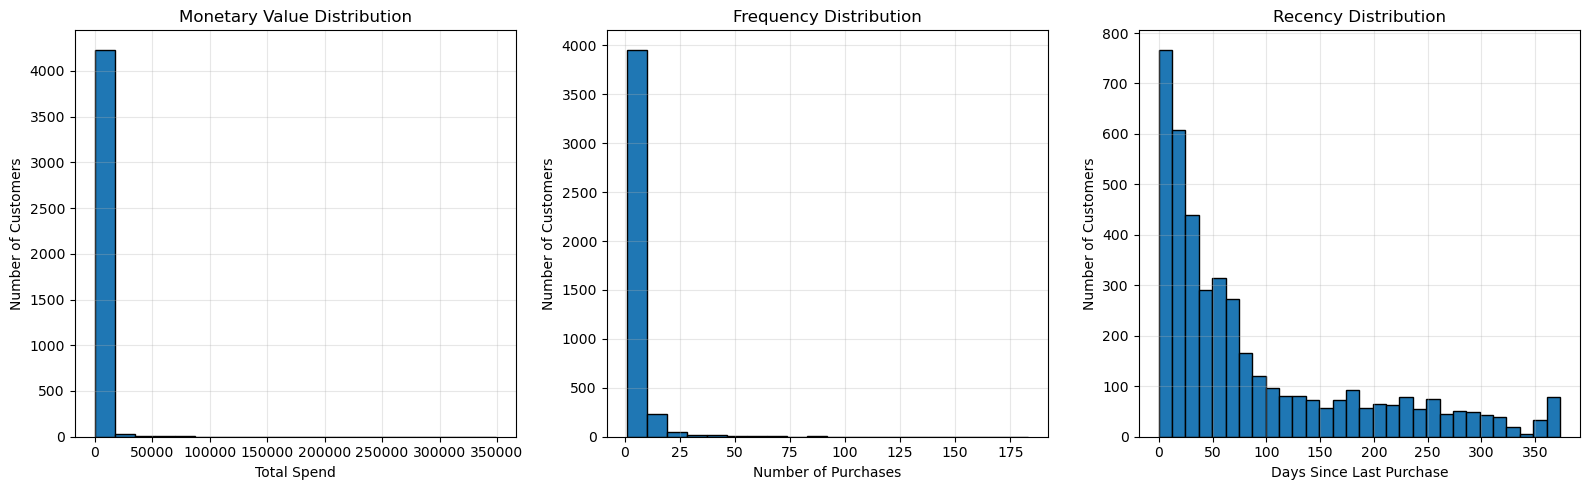

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Monetary Value
axes[0].hist(aggregated_df["MonetaryValue"], bins=20, edgecolor="black")
axes[0].set_title("Monetary Value Distribution")
axes[0].set_xlabel("Total Spend")
axes[0].set_ylabel("Number of Customers")
axes[0].grid(alpha=0.3)

# Frequency
axes[1].hist(aggregated_df["Frequency"], bins=20, edgecolor="black")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Purchases")
axes[1].set_ylabel("Number of Customers")
axes[1].grid(alpha=0.3)

# Recency
axes[2].hist(aggregated_df["Recency"], bins=30, edgecolor="black")
axes[2].set_title("Recency Distribution")
axes[2].set_xlabel("Days Since Last Purchase")
axes[2].set_ylabel("Number of Customers")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


The distributions showed strong skewness, which guided feature scaling and helped justify customer segmentation using RFM features.

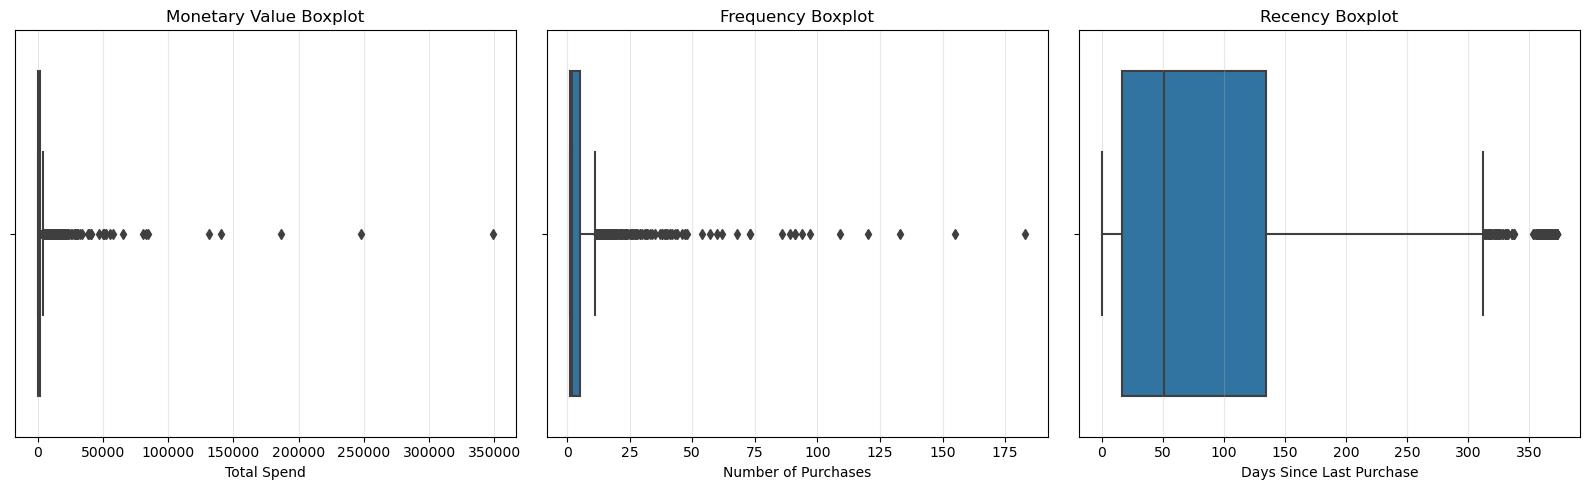

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Monetary Value
sns.boxplot(x=aggregated_df["MonetaryValue"], ax=axes[0])
axes[0].set_title("Monetary Value Boxplot")
axes[0].set_xlabel("Total Spend")
axes[0].grid(axis="x", alpha=0.3)

# Frequency
sns.boxplot(x=aggregated_df["Frequency"], ax=axes[1])
axes[1].set_title("Frequency Boxplot")
axes[1].set_xlabel("Number of Purchases")
axes[1].grid(axis="x", alpha=0.3)

# Recency
sns.boxplot(x=aggregated_df["Recency"], ax=axes[2])
axes[2].set_title("Recency Boxplot")
axes[2].set_xlabel("Days Since Last Purchase")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

The boxplots show that customer behavior is highly skewed, with a small group driving most revenue and purchases.

In [ ]:
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1
monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) |
             (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()
monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.000000,423.000000,423.000000,423,423.000000
mean,15103.040189,12188.101740,17.167849,2010-11-09 12:26:02.978723328,30.035461
min,12357.000000,3802.040000,1.000000,2009-12-10 18:03:00,0.000000
25%,13622.000000,4605.940000,8.000000,2010-11-08 13:17:30,3.000000
50%,14961.000000,6191.320000,12.000000,2010-11-26 12:19:00,13.000000
75%,16692.000000,10273.235000,18.000000,2010-12-06 10:34:30,31.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1728.661406,25830.851045,19.729755,NaN,51.541004


In [ ]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1
frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) |
        (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()
frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14409.714932,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.390000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.560500,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31381.736785,21.932937,NaN,26.589117


In [ ]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) &
                (~aggregated_df.index.isin(frequency_outliers_df.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.000000,3809.000000,3809.000000,3809,3809.000000
mean,15376.482804,885.502197,2.863481,2010-09-03 11:16:46.516146176,97.082174
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,22.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,58.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.199806,817.672283,2.243748,NaN,98.111495


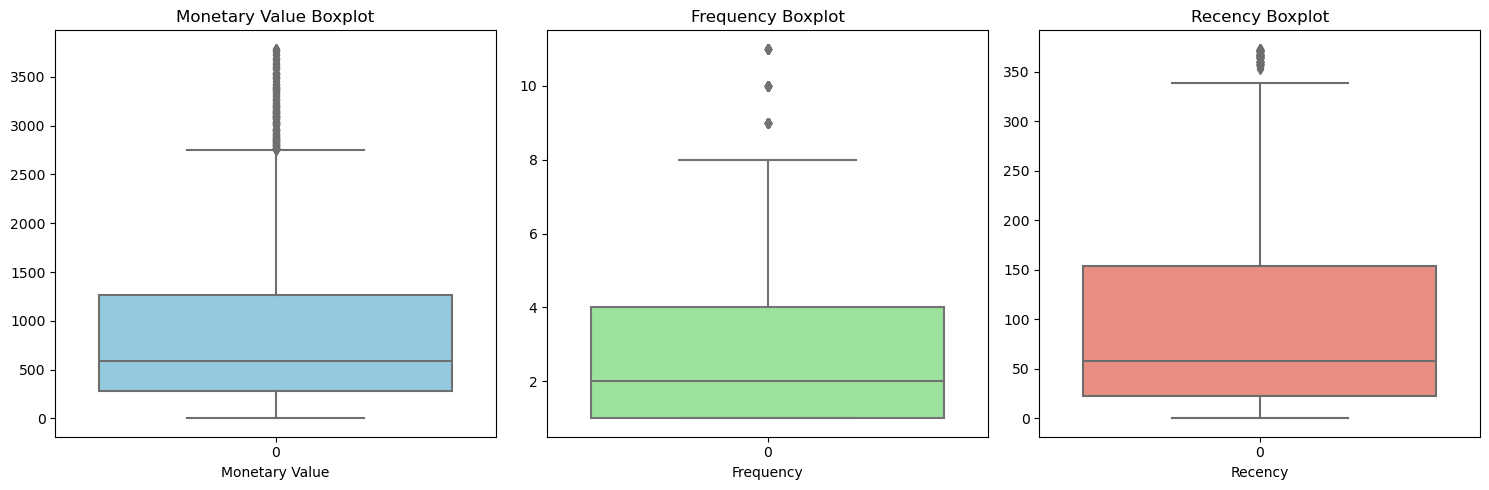

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

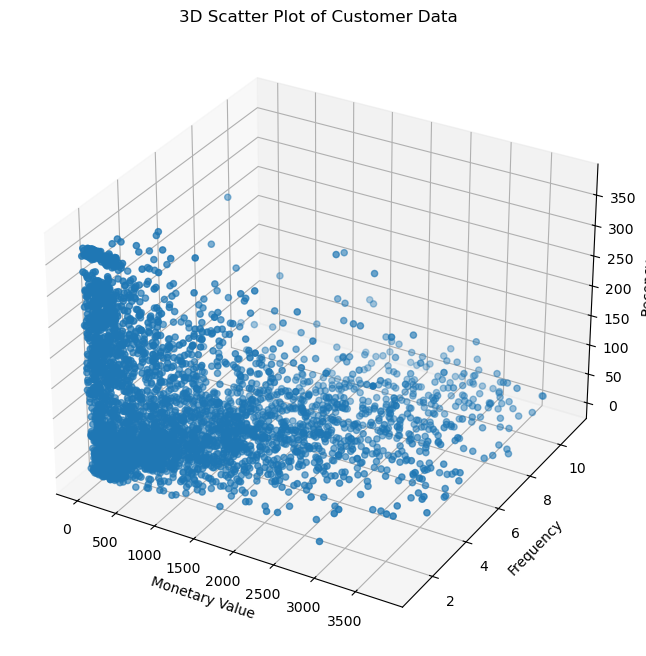

In [ ]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

The 3D RFM scatter plot shows that most customers have low monetary value and low purchase frequency, forming a dense cluster near the origin.

A smaller group of customers exhibits high monetary value with moderate frequency and low recency, indicating valuable and recently active customers.

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[["MonetaryValue", "Frequency", "Recency"]])
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [ ]:
scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index,
             columns=("MonetaryValue", "Frequency", "Recency"))
scaled_data_df.sample(5)

,MonetaryValue,Frequency,Recency
1640,0.964948,0.060852,-0.969251
2253,-0.661589,-0.384889,-0.806150
4119,-0.867212,-0.830631,-0.714405
2005,-0.386859,-0.384889,-0.816344
2361,3.239214,0.952335,-0.112970


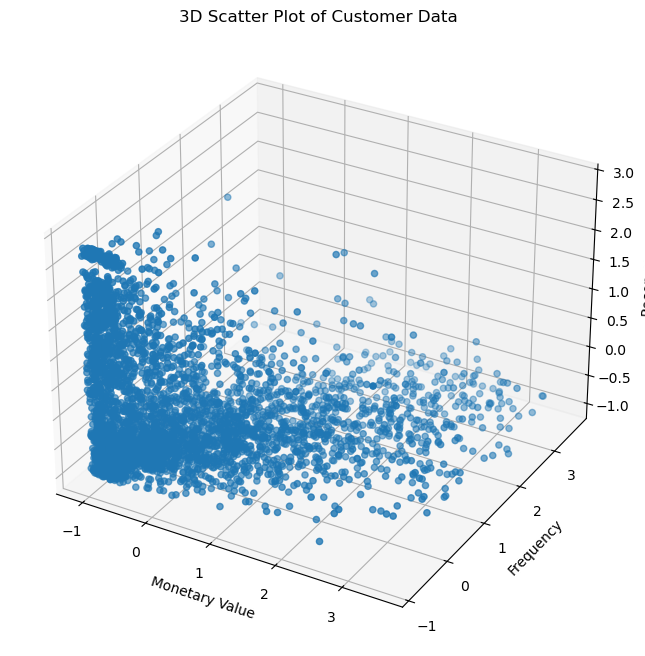

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(scaled_data_df["MonetaryValue"],
        scaled_data_df["Frequency"], scaled_data_df["Recency"])
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

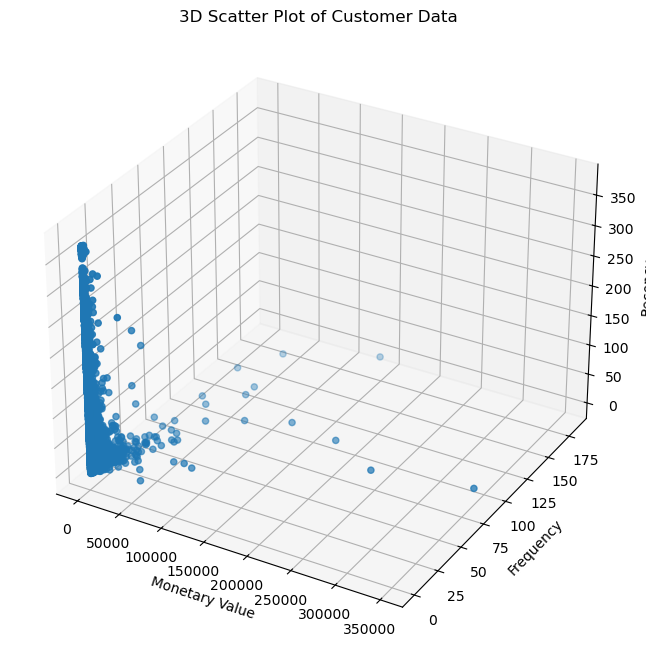

In [ ]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    aggregated_df["MonetaryValue"],
    aggregated_df["Frequency"],
    aggregated_df["Recency"]
)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

### KMeans Clustering

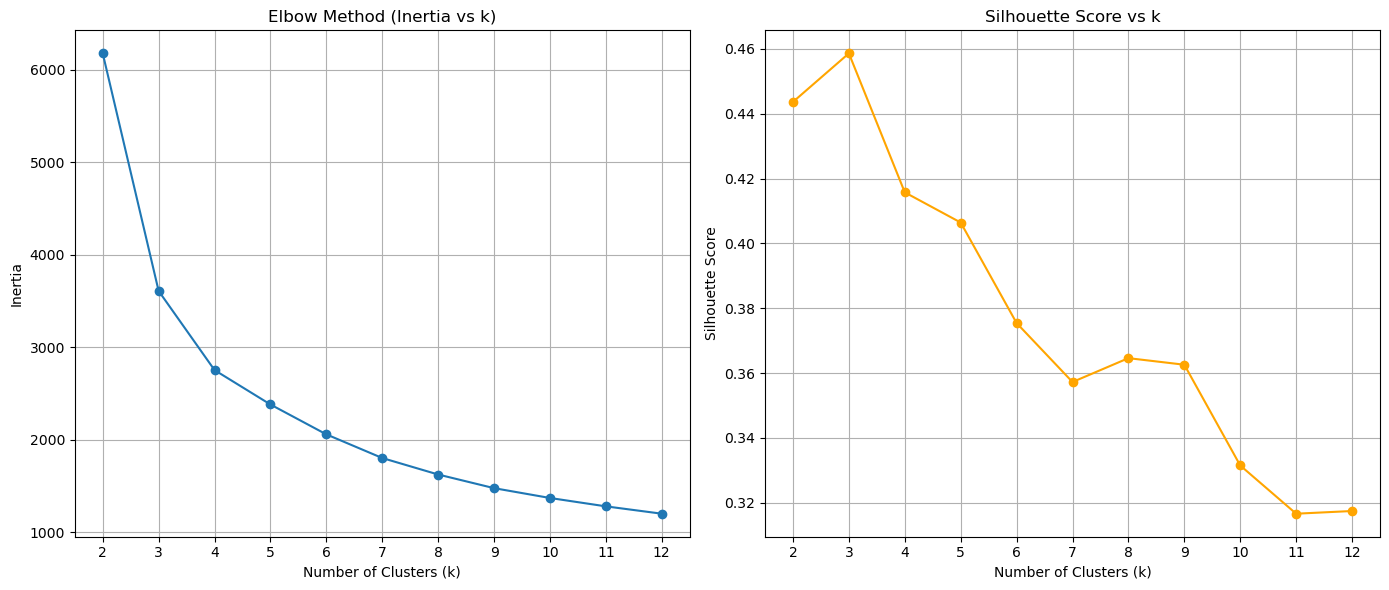

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        max_iter=1000,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(scaled_data_df, cluster_labels)
    )

# Plotting
plt.figure(figsize=(14, 6))
# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)
cluster_labels = kmeans.fit_predict(scaled_data_df)
cluster_labels

array([0, 3, 2, ..., 0, 3, 3])

In [ ]:
non_outliers_df["Cluster"] = cluster_labels
non_outliers_df.sample(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
2223,15479.0,147.40,1,2009-12-06 15:08:00,368,0
1195,14065.0,891.02,3,2010-11-15 16:13:00,24,3
114,12519.0,349.70,1,2010-08-20 08:21:00,111,2
3993,17878.0,1032.88,2,2010-11-09 13:52:00,30,2
204,12683.0,3788.21,8,2010-12-09 12:17:00,0,1


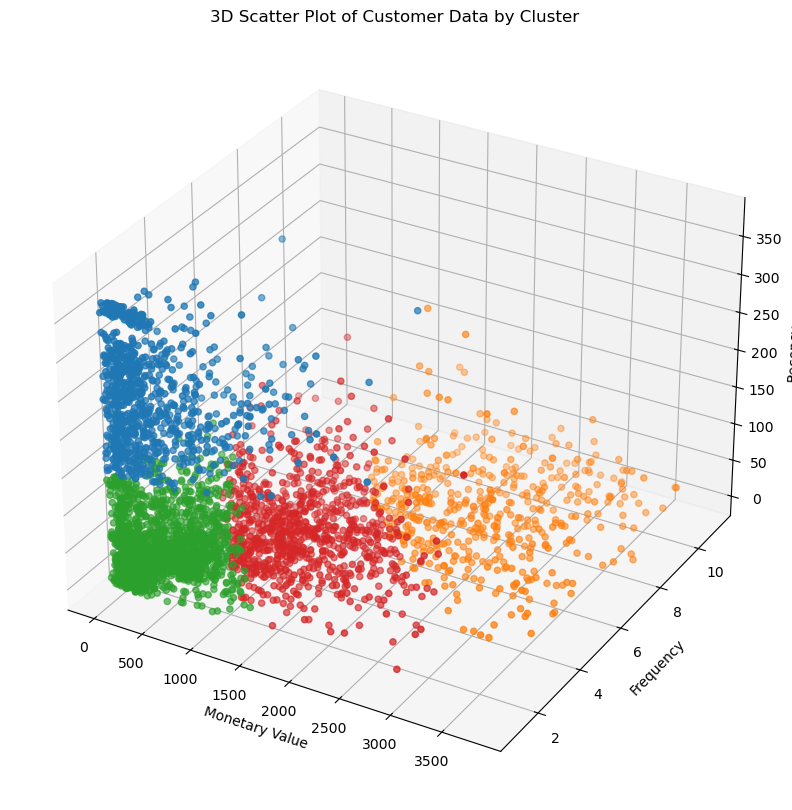

In [ ]:
cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728'}  # Red

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

This 3D RFM plot shows four clearly separable customer segments based on spending, purchase frequency, and recency.

In [ ]:
non_outliers_df.columns

Index(['Customer ID', 'MonetaryValue', 'Frequency', 'LastInvoiceDate',
       'Recency', 'Cluster'],
      dtype='object')

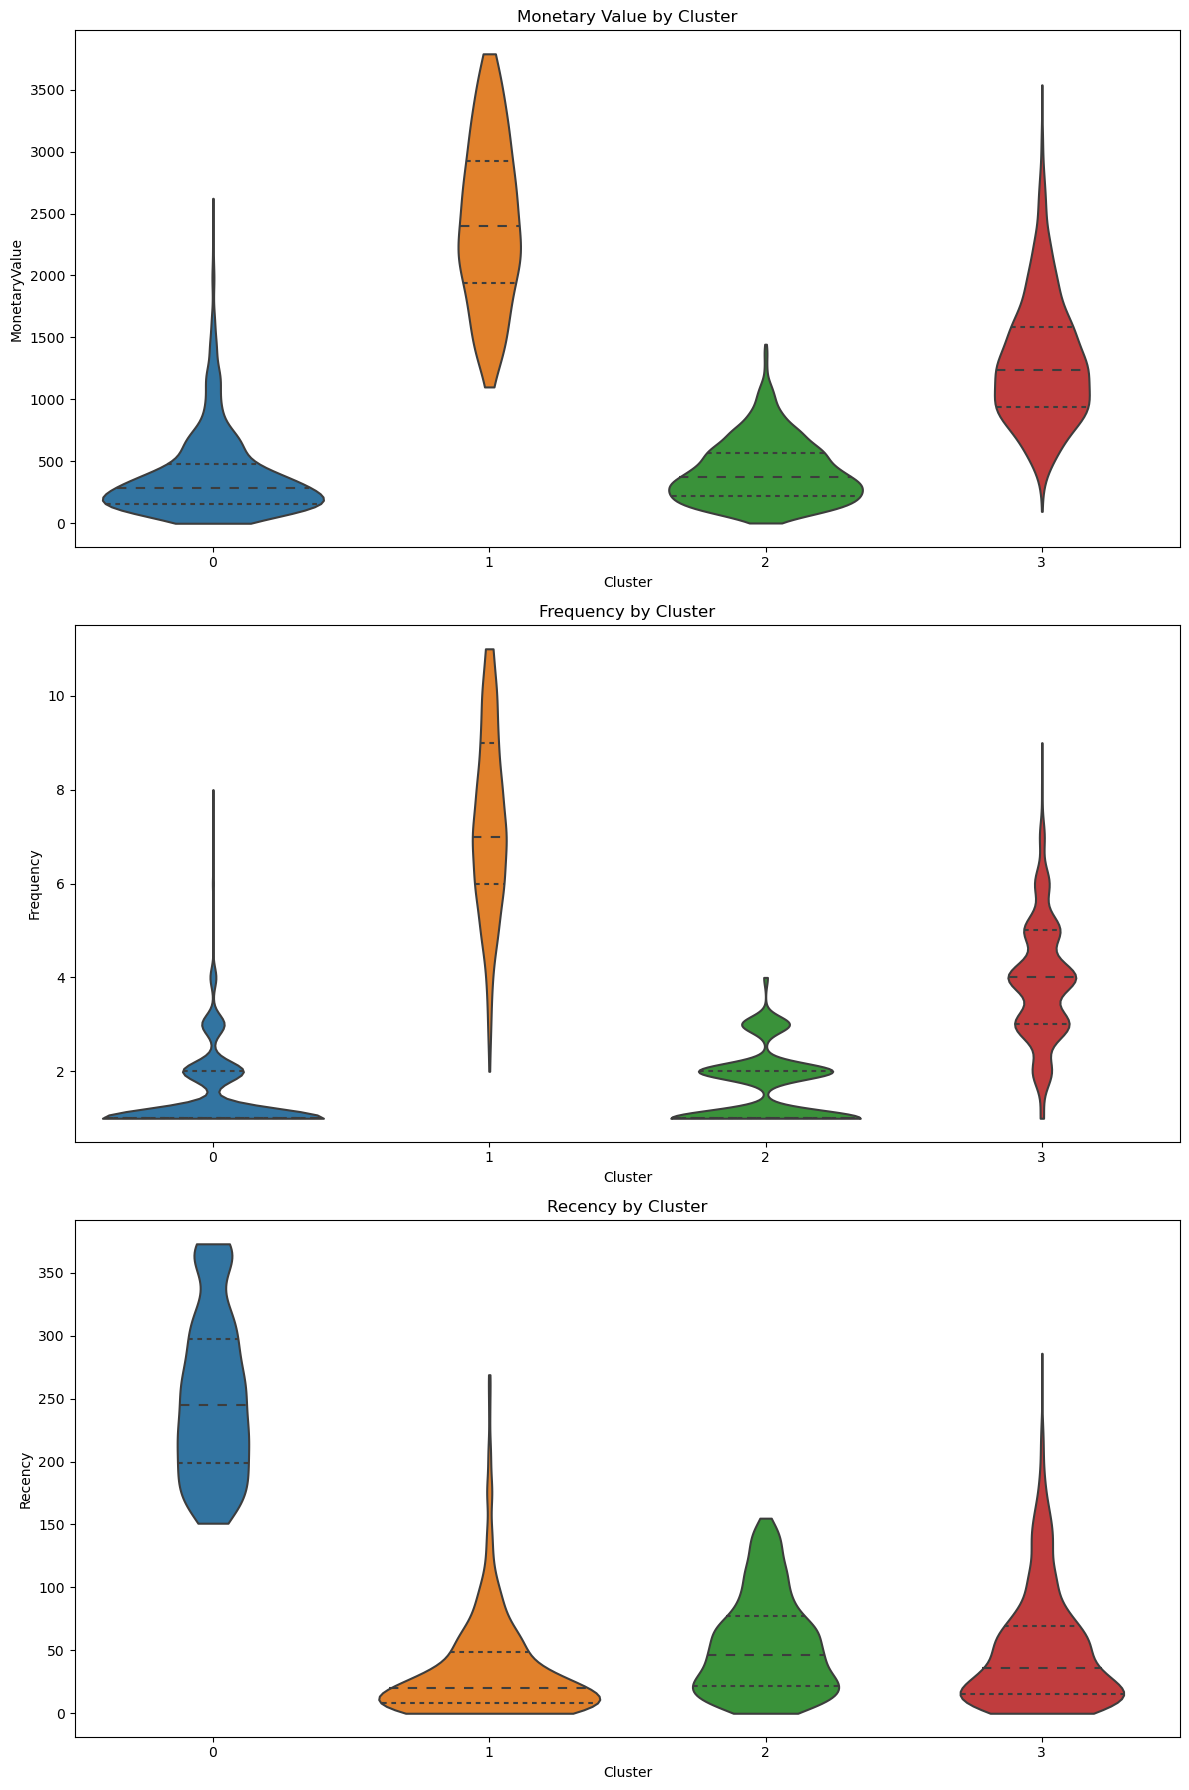

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 18))

# ---------- Monetary ----------
plt.subplot(3, 1, 1)
sns.violinplot(
    x='Cluster',
    y='MonetaryValue',
    data=non_outliers_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Monetary Value by Cluster')

# ---------- Frequency ----------
plt.subplot(3, 1, 2)
sns.violinplot(
    x='Cluster',
    y='Frequency',
    data=non_outliers_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Frequency by Cluster')

# ---------- Recency ----------
plt.subplot(3, 1, 3)
sns.violinplot(
    x='Cluster',
    y='Recency',
    data=non_outliers_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Recency by Cluster')

plt.tight_layout()
plt.show()


In [ ]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


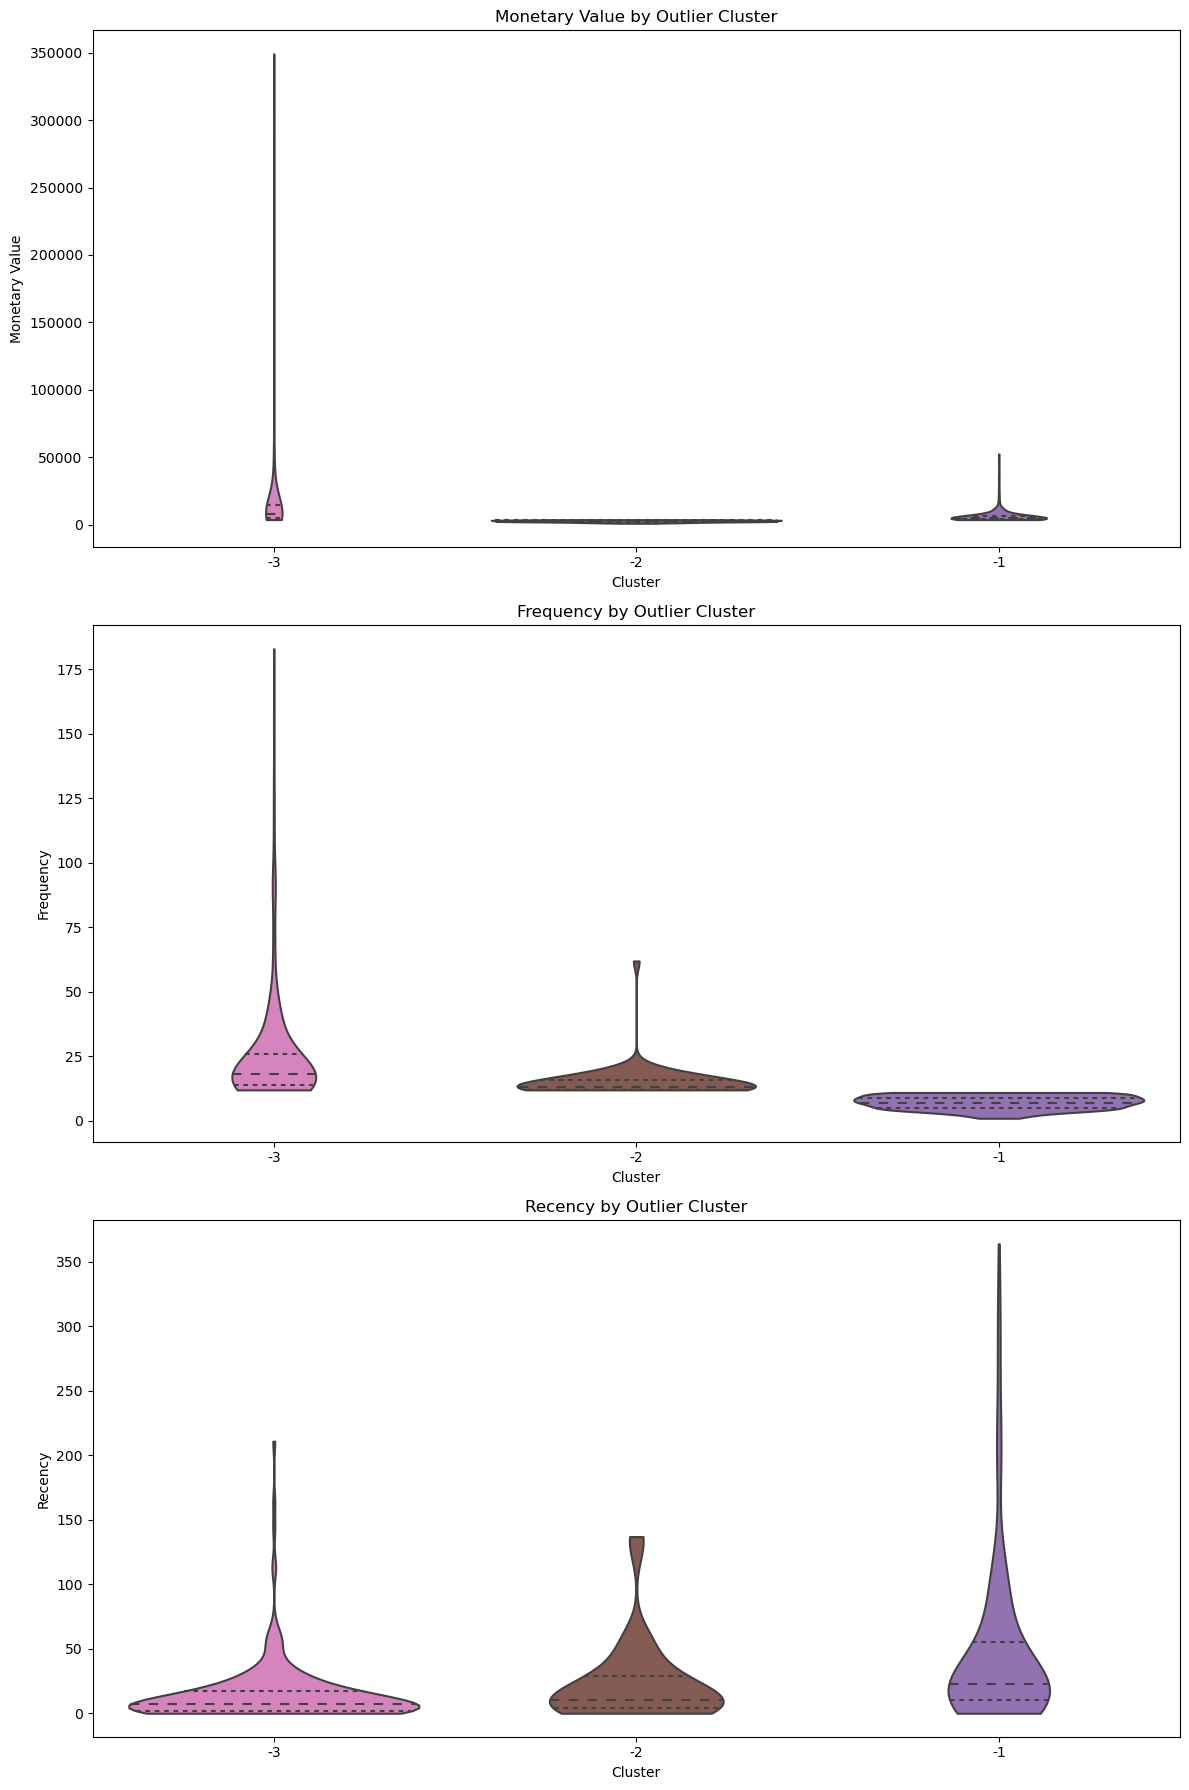

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_colors = {
    -1: '#9467bd',  # purple
    -2: '#8c564b',  # brown
    -3: '#e377c2'   # pink
}

plt.figure(figsize=(12, 18))

# ---------- Monetary ----------
plt.subplot(3, 1, 1)
sns.violinplot(
    x='Cluster',
    y='MonetaryValue',
    data=outlier_clusters_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Monetary Value by Outlier Cluster')
plt.ylabel('Monetary Value')

# ---------- Frequency ----------
plt.subplot(3, 1, 2)
sns.violinplot(
    x='Cluster',
    y='Frequency',
    data=outlier_clusters_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Frequency by Outlier Cluster')
plt.ylabel('Frequency')

# ---------- Recency ----------
plt.subplot(3, 1, 3)
sns.violinplot(
    x='Cluster',
    y='Recency',
    data=outlier_clusters_df,
    palette=cluster_colors,
    inner='quartile',
    cut=0
)
plt.title('Recency by Outlier Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()


In [ ]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [ ]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,0
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,3
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,3
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


In [ ]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,0
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,3
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,3
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


In [ ]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.0,169.36,2,2010-06-28 13:53:00,164,0,RETAIN
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,3,REWARD
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,3,REWARD
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


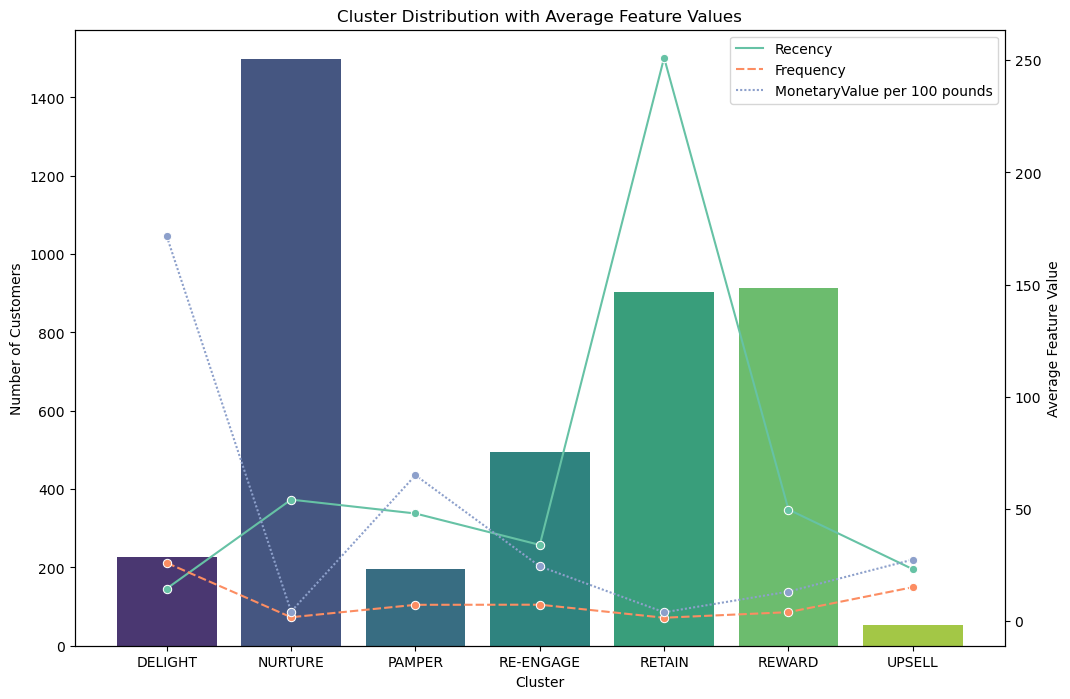

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cluster counts
cluster_counts = full_clustering_df['ClusterLabel'].value_counts().sort_index()

# 2. Scale monetary value
full_clustering_df["MonetaryValue per 100 pounds"] = (
    full_clustering_df["MonetaryValue"] / 100.0
)

# 3. Feature means per cluster
feature_means = (
    full_clustering_df
    .groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']]
    .mean()
)

# 4. Plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Bar plot: number of customers
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    ax=ax1,
    palette='viridis'
)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Cluster')
ax1.set_title('Cluster Distribution with Average Feature Values')

# Secondary axis
ax2 = ax1.twinx()

# Line plot: average RFM values
sns.lineplot(
    data=feature_means,
    ax=ax2,
    marker='o',
    palette='Set2'
)
ax2.set_ylabel('Average Feature Value')

plt.show()


The NURTURE segment contains the largest number of customers, indicating many low-engagement or early-stage buyers who purchase infrequently and contribute relatively low revenue, making them ideal targets for engagement campaigns. RETAIN and REWARD clusters represent active and valuable customers with recent purchases and higher spending, suggesting strong loyalty and high business impact—these customers should be prioritized for retention and loyalty programs. DE-LIGHT and PAMPER segments include customers with high monetary value or frequency but smaller population sizes, highlighting premium or niche high-value customers who can be upsold or given exclusive benefits. UPSELL, although small in size, shows higher frequency and spending potential, indicating opportunities for targeted cross-sell and upsell strategies.